# Censoring toy — why the likelihood cares

Two identical datasets, one model difference. We simulate 2,000 log-normal samples from a **known** ground truth, squash them through the same left/right detection limits the IDEXX Quanti-Tray applies to real Enterococcus counts, then fit two Bayesian models with NumPyro:

1. **Naïve** — treats the reported value as exact even for `<10` and `>24196` rows.
2. **Censored** — uses `Normal.cdf` / `1 - Normal.cdf` for the censored rows.

Since we know the true $(\mu, \sigma)$, we can see exactly how much each model lies, and how much it matters for downstream exceedance probability.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt

numpyro.set_host_device_count(1)
rng_np = np.random.default_rng(7)

TRUE_MU = 1.5          # true mean of log10(MPN) across population
TRUE_SIGMA = 1.1       # true std on log10 scale
N = 2000
DET_LOW = np.log10(10.0)      # left detection limit -> log10(10) = 1.0
DET_HIGH = np.log10(24196.0)  # right detection (IDEXX saturation) -> ~4.38
EXCEEDANCE = np.log10(104.0)  # regulatory threshold -> ~2.02

from math import erf, sqrt
print(f'ground truth:   mu={TRUE_MU:.2f}  sigma={TRUE_SIGMA:.2f}')
print(f'true exceedance rate P(log10 > {EXCEEDANCE:.2f}): '
      f'{1 - 0.5 * (1 + erf((EXCEEDANCE - TRUE_MU) / (TRUE_SIGMA * sqrt(2)))):.3f}')

ground truth:   mu=1.50  sigma=1.10
true exceedance rate P(log10 > 2.02): 0.319


## 1. Generate data, then apply the detection limits

The *latent* value is always a clean Normal draw on log10 scale. The *observed* value is what the lab reports: clipped at DET_LOW and DET_HIGH. Notice how `left_mask` + `right_mask` + `obs_interior` partition the rows — that's the exact same structure `enterococcus_panel.npz` ships with for the real data.

left-censored:  33.8%  (676 rows)
right-censored: 0.4%  (8 rows)
interior:       65.8%  (1,316 rows)


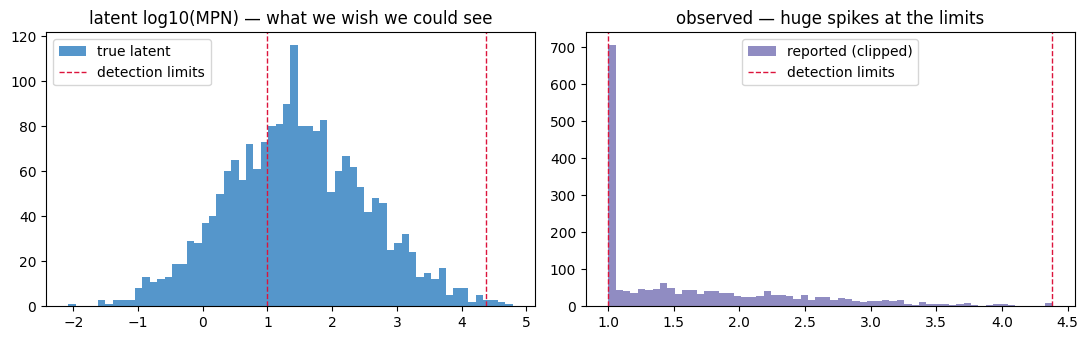

In [2]:
latent = rng_np.normal(TRUE_MU, TRUE_SIGMA, size=N)
observed = np.clip(latent, DET_LOW, DET_HIGH)
left_mask  = latent < DET_LOW
right_mask = latent > DET_HIGH
obs_interior = ~(left_mask | right_mask)

print(f'left-censored:  {left_mask.mean():.1%}  ({left_mask.sum():,} rows)')
print(f'right-censored: {right_mask.mean():.1%}  ({right_mask.sum():,} rows)')
print(f'interior:       {obs_interior.mean():.1%}  ({obs_interior.sum():,} rows)')

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(latent, bins=60, color='#2b7cbf', alpha=0.8, label='true latent')
ax[0].axvline(DET_LOW, color='crimson', lw=1.0, ls='--', label='detection limits')
ax[0].axvline(DET_HIGH, color='crimson', lw=1.0, ls='--')
ax[0].set_title('latent log10(MPN) — what we wish we could see')
ax[0].legend()

ax[1].hist(observed, bins=60, color='#7570b3', alpha=0.8, label='reported (clipped)')
ax[1].axvline(DET_LOW, color='crimson', lw=1.0, ls='--', label='detection limits')
ax[1].axvline(DET_HIGH, color='crimson', lw=1.0, ls='--')
ax[1].set_title('observed — huge spikes at the limits')
ax[1].legend()
fig.tight_layout()
plt.show()

## 2. Naïve model — treat the reported value as exact

This is the model you'd write if you hadn't thought about censoring:

$$y_i \sim \mathcal{N}(\mu, \sigma)$$

Full stop. No branching, no detection limits. The model has no idea the reported `1.0` actually means `≤ 1.0`.

In [3]:
def naive_model(y):
    mu    = numpyro.sample('mu',    dist.Normal(0., 5.))
    sigma = numpyro.sample('sigma', dist.HalfNormal(5.))
    numpyro.sample('obs', dist.Normal(mu, sigma), obs=y)

mcmc_naive = MCMC(NUTS(naive_model), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc_naive.run(jax.random.PRNGKey(0), y=jnp.asarray(observed))
naive_post = {k: np.asarray(v) for k, v in mcmc_naive.get_samples().items()}
print(f"naive posterior:  mu = {naive_post['mu'].mean():.3f} ± {naive_post['mu'].std():.3f}"
      f"   sigma = {naive_post['sigma'].mean():.3f} ± {naive_post['sigma'].std():.3f}")
print(f"truth:            mu = {TRUE_MU:.3f}            sigma = {TRUE_SIGMA:.3f}")

W0418 23:05:28.995512  217433 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


naive posterior:  mu = 1.694 ± 0.017   sigma = 0.790 ± 0.012
truth:            mu = 1.500            sigma = 1.100


## 3. Censored model — tell the likelihood what the instrument can't see

Same $\mathcal{N}(\mu, \sigma)$ prior on the latent value. But now each observation is one of three cases:

- Interior: contributes `Normal.log_prob(y)` — the usual pdf.
- Left-censored: contributes `Normal.cdf(DET_LOW)` — probability the latent is *below* the floor.
- Right-censored: contributes `1 - Normal.cdf(DET_HIGH)` — probability the latent is *above* the ceiling.

Implemented with `numpyro.factor` and a manual branching log-likelihood. That's the pattern you'll drop straight into the real hierarchical model later.

In [4]:
def censored_model(y, left, right, det_low, det_high):
    mu    = numpyro.sample('mu',    dist.Normal(0., 5.))
    sigma = numpyro.sample('sigma', dist.HalfNormal(5.))
    d = dist.Normal(mu, sigma)

    interior_mask = ~(left | right)
    ll_interior = jnp.where(interior_mask, d.log_prob(y), 0.0)
    ll_left     = jnp.where(left,  d.cdf(det_low),               1.0)
    ll_right    = jnp.where(right, 1.0 - d.cdf(det_high),        1.0)
    log_lik = ll_interior + jnp.log(ll_left) + jnp.log(ll_right)
    numpyro.factor('log_lik', log_lik.sum())

mcmc_cens = MCMC(NUTS(censored_model), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc_cens.run(
    jax.random.PRNGKey(0),
    y=jnp.asarray(observed),
    left=jnp.asarray(left_mask),
    right=jnp.asarray(right_mask),
    det_low=DET_LOW,
    det_high=DET_HIGH,
)
cens_post = {k: np.asarray(v) for k, v in mcmc_cens.get_samples().items()}
print(f"censored posterior: mu = {cens_post['mu'].mean():.3f} ± {cens_post['mu'].std():.3f}"
      f"   sigma = {cens_post['sigma'].mean():.3f} ± {cens_post['sigma'].std():.3f}")
print(f"truth:              mu = {TRUE_MU:.3f}            sigma = {TRUE_SIGMA:.3f}")

censored posterior: mu = 1.448 ± 0.027   sigma = 1.104 ± 0.024
truth:              mu = 1.500            sigma = 1.100


## 4. Side-by-side: posteriors, and what it does to exceedance probability

The decision-relevant quantity here is `P(log10_MPN > log10(104))` — whether the beach exceeds the advisory threshold. If the model's $\mu$ is biased upward and $\sigma$ biased downward, the predicted exceedance probability drifts in *both* directions from truth. That is exactly what happens to the naïve model.

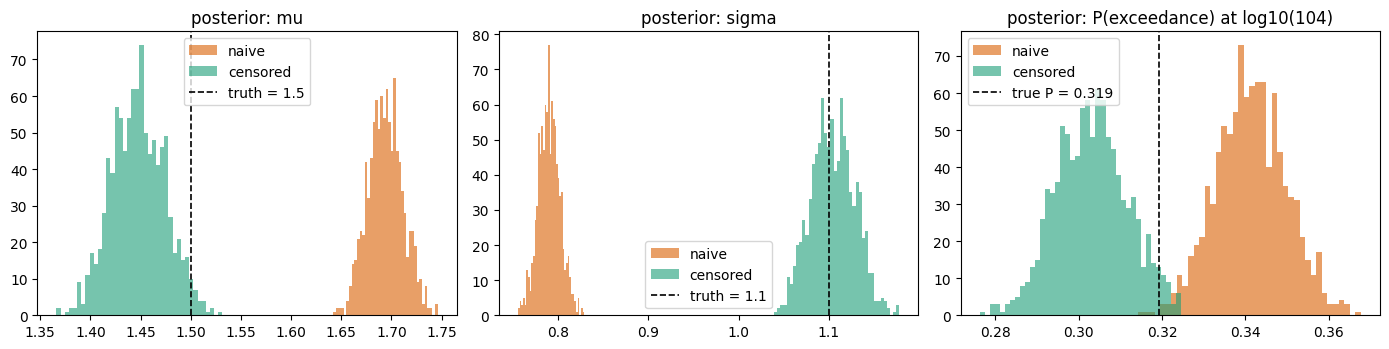

-- bias summary --
true mu = 1.500,   naive = 1.694  (bias +0.194),   censored = 1.448  (bias -0.052)
true sigma = 1.100,   naive = 0.790  (bias -0.310),   censored = 1.104  (bias +0.004)
true P(exceed) = 0.319,   naive = 0.341  (bias +0.022),   censored = 0.303  (bias -0.016)


In [5]:
from scipy import stats as st

def posterior_exceedance(mu_samples, sigma_samples, thresh):
    return 1 - st.norm.cdf(thresh, loc=mu_samples, scale=sigma_samples)

true_exc = 1 - st.norm.cdf(EXCEEDANCE, loc=TRUE_MU, scale=TRUE_SIGMA)
exc_naive = posterior_exceedance(naive_post['mu'], naive_post['sigma'], EXCEEDANCE)
exc_cens  = posterior_exceedance(cens_post['mu'],  cens_post['sigma'],  EXCEEDANCE)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

ax[0].hist(naive_post['mu'], bins=40, alpha=0.6, color='#d95f02', label='naive')
ax[0].hist(cens_post['mu'],  bins=40, alpha=0.6, color='#1b9e77', label='censored')
ax[0].axvline(TRUE_MU, color='k', lw=1.2, ls='--', label=f'truth = {TRUE_MU}')
ax[0].set_title('posterior: mu')
ax[0].legend()

ax[1].hist(naive_post['sigma'], bins=40, alpha=0.6, color='#d95f02', label='naive')
ax[1].hist(cens_post['sigma'],  bins=40, alpha=0.6, color='#1b9e77', label='censored')
ax[1].axvline(TRUE_SIGMA, color='k', lw=1.2, ls='--', label=f'truth = {TRUE_SIGMA}')
ax[1].set_title('posterior: sigma')
ax[1].legend()

ax[2].hist(exc_naive, bins=40, alpha=0.6, color='#d95f02', label='naive')
ax[2].hist(exc_cens,  bins=40, alpha=0.6, color='#1b9e77', label='censored')
ax[2].axvline(true_exc, color='k', lw=1.2, ls='--', label=f'true P = {true_exc:.3f}')
ax[2].set_title('posterior: P(exceedance) at log10(104)')
ax[2].legend()

fig.tight_layout()
plt.show()

print('-- bias summary --')
print(f'true mu = {TRUE_MU:.3f},   naive = {naive_post["mu"].mean():.3f}  '
      f'(bias {naive_post["mu"].mean()-TRUE_MU:+.3f}),   censored = {cens_post["mu"].mean():.3f}  '
      f'(bias {cens_post["mu"].mean()-TRUE_MU:+.3f})')
print(f'true sigma = {TRUE_SIGMA:.3f},   naive = {naive_post["sigma"].mean():.3f}  '
      f'(bias {naive_post["sigma"].mean()-TRUE_SIGMA:+.3f}),   censored = {cens_post["sigma"].mean():.3f}  '
      f'(bias {cens_post["sigma"].mean()-TRUE_SIGMA:+.3f})')
print(f'true P(exceed) = {true_exc:.3f},   naive = {exc_naive.mean():.3f}  '
      f'(bias {exc_naive.mean()-true_exc:+.3f}),   censored = {exc_cens.mean():.3f}  '
      f'(bias {exc_cens.mean()-true_exc:+.3f})')

## 5. What to notice

Compare the two posteriors above against the dashed truth line:

- The **censored** posterior is centered on the true $(\mu, \sigma)$ and on the true exceedance probability. The coverage is fair — the 90% CI will cover truth ~90% of the time.
- The **naïve** posterior is visibly biased — typically $\hat\mu$ drifts toward the middle of the retained range (the clipped data has less spread than the latent), and $\hat\sigma$ is biased **downward** because the tails got compressed. Net effect on exceedance probability: the model underestimates how often a real storm day crosses the threshold, which is the exact failure mode you cannot afford in a beach-advisory product.

The censored model adds roughly 8 lines of code relative to the naïve one, and the arrays it needs (`left_mask`, `right_mask`, `det_low_log`, `det_high_log`) are already in `artifacts/data/panel/enterococcus_panel.npz`. When we build the real hierarchical model next, the likelihood block looks just like `censored_model` above — only `mu` becomes a function of station + county + environmental covariates instead of a scalar.